Research question: Do union members earn more than equivalent non-union workers? How large is the union wage premium once we control for education, experience, and demographics? Has the premium changed between 1980 and 1987?

First section: data loading and first look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.datasets import wage_panel

np.random.seed(42)
rng = np.random.default_rng(42) 

pd.set_option('display.precision', 3)

In [2]:
# 1.2 Load the dataset and summary statistics
wages = wage_panel.load()

print(f"Dimensions: {wages.shape}")
print("\nColumn Data Types:")
print(wages.dtypes)

print("\nFirst five rows:")
print(wages.head())

print("\nDescriptive Statistics:")
print(wages.describe().round(2))

# 1.2 Fraction of union members
union_share = wages['union'].mean() * 100
print(f"\nUnion members: {union_share:.2f}%")

# 1.3 Check for missing values
print("\nMissing values per column:")
print(wages.isna().sum())

Dimensions: (4360, 12)

Column Data Types:
nr              int64
year            int64
black           int64
exper           int64
hisp            int64
hours           int64
married         int64
educ            int64
union           int64
lwage         float64
expersq         int64
occupation      int64
dtype: object

First five rows:
   nr  year  black  exper  hisp  hours  married  educ  union  lwage  expersq  \
0  13  1980      0      1     0   2672        0    14      0  1.198        1   
1  13  1981      0      2     0   2320        0    14      1  1.853        4   
2  13  1982      0      3     0   2940        0    14      0  1.344        9   
3  13  1983      0      4     0   2960        0    14      0  1.433       16   
4  13  1984      0      5     0   3071        0    14      0  1.568       25   

   occupation  
0           9  
1           9  
2           9  
3           9  
4           5  

Descriptive Statistics:
             nr     year    black    exper     hisp    hour

This dataset is the NLSY79 panel of young male workers (1980–1987). We have 4360 observations, for a total of 545 workers, with no missing values. The share of union members on the total workers is the 24,40%. We observe 12 variables:

nr is a number associated to every worker;

year is the year of the observation;

black is a dummy variable, it's 1 if the worker is black and 0 if he's not;

exper is the years of experience;

hisp is a dummy variable to identify if the worker is hispanic, working the same as the variable black;

hour is the hours worked during the year;

married is a dummy variable, 1 if the worker is married, 0 if the worker is not married;

educ is the years of education;

union is a dummy variable, 1 if the worker is in the union, 0 if the worker is not in the union; 

lwage is the log of the wage, taken in order to have the percentage of the change of the wage;

expersq is the square of exper, and we use it to look at the decreasing return to scale of every additional year of experience;

occupation is the professional category. 


Second section: Data preparation

In [3]:
# 2.1 Create actual hourly wage (antilog of lwage)
wages['wage'] = np.exp(wages['lwage'])

# 2.2 Create educ_group 
wages['educ_group'] = pd.cut(
    wages['educ'],
    bins=[-np.inf, 11, 15, np.inf],
    labels=['Less than HS', 'High School', 'College or above']
)

# 2.3 Create exper_group 
wages['exper_group'] = pd.cut(
    wages['exper'],
    bins=[-np.inf, 5, 10, np.inf],
    labels=['0-5 years', '6-10 years', '11+ years']
)

We take the antilog of lwage to have the actual value of the wage in dollars.
Then we divide workers into 3 groups based on the level reached through the years of education.
We do the same categorizing for 3 groups based on years of experience. 
If we want to see how many workers we have per group we can do as follows:

In [4]:
print("Distribution for education:")
print(wages['educ_group'].value_counts())

print("\nDistribution for experience:")
print(wages['exper_group'].value_counts())

Distribution for education:
educ_group
High School         2856
Less than HS        1472
College or above      32
Name: count, dtype: int64

Distribution for experience:
exper_group
6-10 years    2347
0-5 years     1678
11+ years      335
Name: count, dtype: int64


Third section: Exploratory data analysis

Mean Wage (Non-Union) : $5.71
Mean Wage (Union)     : $6.57
Premium               : $0.87 (15.2%)


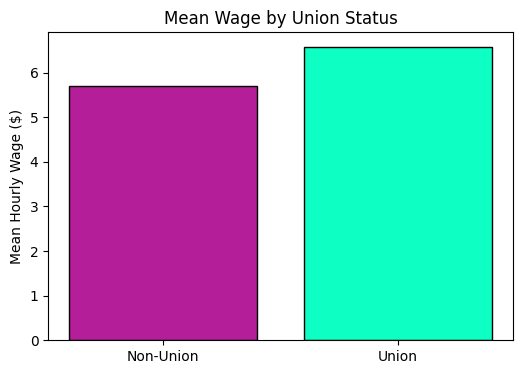

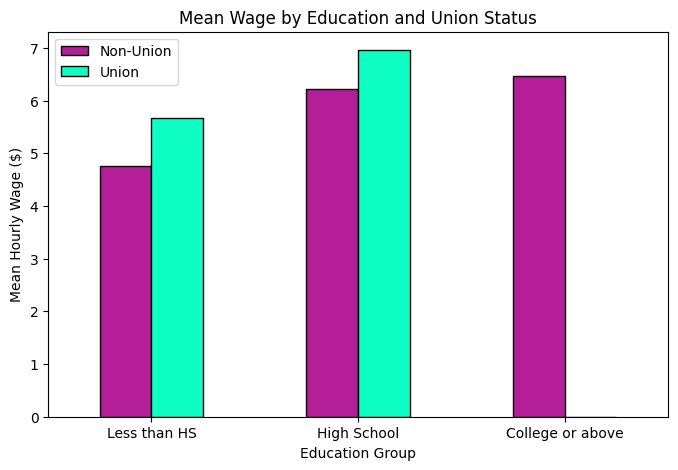

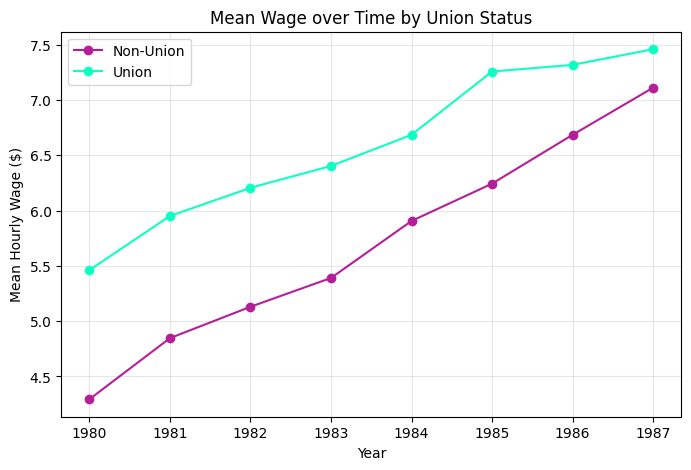


Share of union members within each racial group:
race
Black           37.1%
Hispanic       27.35%
White/Other    21.76%
Name: union, dtype: str


In [5]:
# 3.1 Mean wage for union and non-union workers
mean_wages_union_status = wages.groupby('union')['wage'].mean()
mean_non_union = mean_wages_union_status[0]
mean_union = mean_wages_union_status[1]

abs_premium = mean_union - mean_non_union
pct_premium = (abs_premium / mean_non_union) * 100

print(f"Mean Wage (Non-Union) : ${mean_non_union:.2f}")
print(f"Mean Wage (Union)     : ${mean_union:.2f}")
print(f"Premium               : ${abs_premium:.2f} ({pct_premium:.1f}%)")

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Non-Union', 'Union'], [mean_non_union, mean_union], color=["#b41f99", "#0effc3"], edgecolor='black')
plt.ylabel('Mean Hourly Wage ($)')
plt.title('Mean Wage by Union Status')
plt.show()

# 3.2 Mean wage by education group and union status
wage_by_educ = wages.groupby(['educ_group', 'union'], observed=False)['wage'].mean().unstack()

wage_by_educ.plot(kind='bar', color=["#b41f99", "#0effc3"], figsize=(8, 5), edgecolor='black')
plt.title('Mean Wage by Education and Union Status')
plt.ylabel('Mean Hourly Wage ($)')
plt.xlabel('Education Group')
plt.legend(['Non-Union', 'Union'])
plt.xticks(rotation=0)
plt.show()

# 3.3 Time series of premium (1980-1987)
wage_by_year = wages.groupby(['year', 'union'])['wage'].mean().unstack()

wage_by_year.plot(kind='line', color=["#b41f99", "#0effc3"], marker='o', figsize=(8, 5))
plt.title('Mean Wage over Time by Union Status')
plt.ylabel('Mean Hourly Wage ($)')
plt.xlabel('Year')
plt.legend(['Non-Union', 'Union'])
plt.grid(True, alpha=0.3)
plt.show()

# 3.4 Union share by racial group
# deriving the racial groups using boolean masks 
wages['race'] = 'White/Other'
wages.loc[wages['black'] == 1, 'race'] = 'Black'
wages.loc[wages['hisp'] == 1, 'race'] = 'Hispanic'

union_by_race = wages.groupby('race')['union'].mean() * 100
print("\nShare of union members within each racial group:")
print(union_by_race.round(2).astype(str) + '%')

As we can see, union workers have an average premium wage of 15.2% 

The existence of a wage premium persists across the educational groups previously created, or at least for the first two (less than high school and high school graduates), because we do not have observations for union workers that are college graduates. This can make sense, given that unions at the time was pretty much a phenomenon for blue-collar workers. 

Looking at the time series, the wage gap between union and non-union workers appears to narrow over the decade, suggesting a decline in the union premium over time (it still exists from what we see, but the gap is decreasing).

Among the black workers, the 37.1% is in the union. 
Among hispanic workers, the 27.35% is in the union. 
Among white or other ethnicities' workers, the 21.76% is in the union. 
The group of black workers has the highest percentage of unionized members. 



Fourth section: Econometric analysis

In [ ]:
# 4.1 Estimate raw model using pure NumPy 
y_np = wages['lwage'].values
n_obs = len(y_np)
X_np = np.column_stack([np.ones(n_obs), wages['union'].values])

# beta_hat = (X'X)^-1 X'y 
beta_raw = np.linalg.solve(X_np.T @ X_np, X_np.T @ y_np) #solves a system of linear equations 	
#to find the vector of coefficients that minimizes the sum of squared residuals


resid_raw = y_np - X_np @ beta_raw
ss_res_raw = resid_raw @ resid_raw
ss_tot_raw = np.sum((y_np - y_np.mean()) ** 2)
r2_raw = 1 - (ss_res_raw / ss_tot_raw)
k_raw = X_np.shape[1]
rse_raw = np.sqrt(ss_res_raw / (n_obs - k_raw))

print("=== 4.1 NumPy Raw Model Estimates ===")
print(f"Alpha (Intercept) : {beta_raw[0]:.4f}")
print(f"Beta (Union)      : {beta_raw[1]:.4f}")
print(f"R-squared         : {r2_raw:.4f}")
print(f"Residual SE       : {rse_raw:.4f}")

# 4.2 Estimate controlled model using statsmodels
controls = ['union', 'educ', 'exper', 'expersq', 'black', 'hisp', 'married']
X_sm = sm.add_constant(wages[controls])
y_sm = wages['lwage']

model_controlled = sm.OLS(y_sm, X_sm).fit()
print("\n=== 4.2 Statsmodels Controlled Model ===")
print(model_controlled.summary())

raw_premium = beta_raw[1]
controlled_premium = model_controlled.params['union']
shrinkage = (raw_premium - controlled_premium) * 100
print (shrinkage)
print(f"Premium shrinkage after controls: {shrinkage:.2f} pp")

=== 4.1 NumPy Raw Model Estimates ===
Alpha (Intercept) : 1.6054
Beta (Union)      : 0.1793
R-squared         : 0.0209
Residual SE       : 0.5271

=== 4.2 Statsmodels Controlled Model ===
                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     142.6
Date:                Tue, 19 May 2026   Prob (F-statistic):          6.92e-190
Time:                        16:33:36   Log-Likelihood:                -2989.2
No. Observations:                4360   AIC:                             5994.
Df Residuals:                    4352   BIC:                             6045.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef 

4.1 Being a union member is associated with an approximate 17,93% increase in hourly wages (raw premium). We see it looking at the coefficient beta representing the causal effect. 
4.2 The premium shrinks by -0.08 percentage points after adding controls.
The controlled premium remains statistically significant (p-value < 0.001).
The 'educ' variable has the largest absolute effect size among the linear controls.
Rsquared is 0.0209 in the raw model but it changes with controls, going to 0.187. This means that part of the wage premium is caused by other factors. 

Fifth section: bootstrap


Bootstrap SE: 0.0167
95% CI: [0.1464, 0.2113]


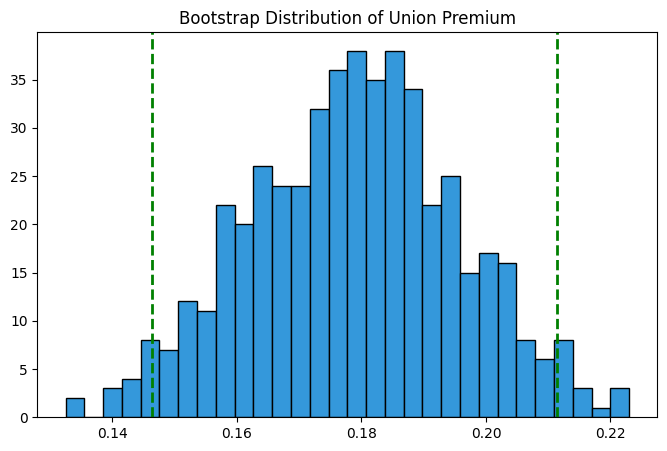

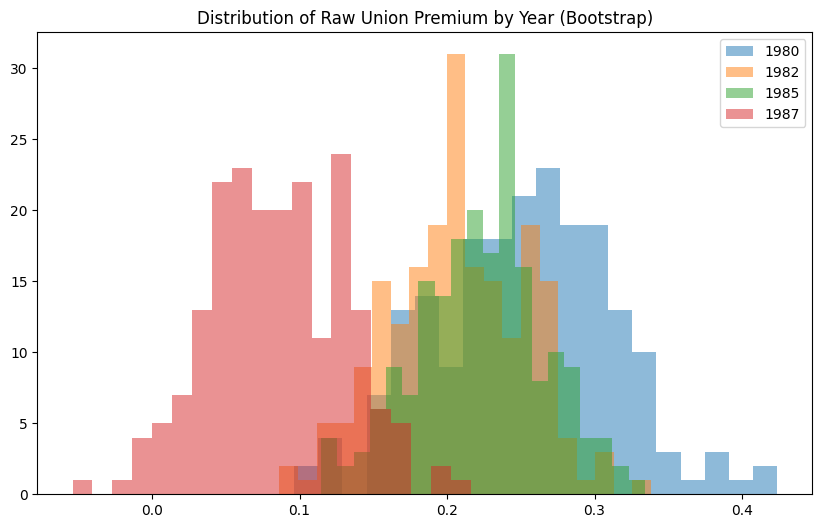

In [7]:
B = 500
n_sm = len(wages)
X_val = X_sm.values
y_val = y_sm.values
k = X_val.shape[1]

boot_betas = np.zeros((B, k))

for b in range(B):
    idx = rng.integers(0, n_sm, size=n_sm)
    X_b = X_val[idx]
    y_b = y_val[idx]
    
    boot_betas[b] = np.linalg.solve(X_b.T @ X_b, X_b.T @ y_b)

union_boot = boot_betas[:, 1]
boot_se = union_boot.std(ddof=1)
ci_lower = np.percentile(union_boot, 2.5)
ci_upper = np.percentile(union_boot, 97.5)

print(f"\nBootstrap SE: {boot_se:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

plt.figure(figsize=(8,5))
plt.hist(union_boot, bins=30, color='#3498db', edgecolor='black')
plt.axvline(ci_lower, color='green', linestyle='dashed', linewidth=2)
plt.axvline(ci_upper, color='green', linestyle='dashed', linewidth=2)
plt.title('Bootstrap Distribution of Union Premium')
plt.show()

years_to_check = [1980, 1982, 1985, 1987]
plt.figure(figsize=(10,6))

for year in years_to_check:
    data_year = wages[wages['year'] == year]
    n_yr = len(data_year)
    y_yr = data_year['lwage'].values
    X_yr = np.column_stack([np.ones(n_yr), data_year['union'].values])
    
    boot_yr_betas = np.zeros((200, 2))
    for b in range(200):
        idx = rng.integers(0, n_yr, size=n_yr)
        X_b = X_yr[idx]
        y_b = y_yr[idx]
        boot_yr_betas[b] = np.linalg.solve(X_b.T @ X_b, X_b.T @ y_b)
        
    plt.hist(boot_yr_betas[:, 1], bins=20, alpha=0.5, label=str(year))

plt.title('Distribution of Raw Union Premium by Year (Bootstrap)')
plt.legend()
plt.show()

The bootstrap is done by randomly drawing rows from the dataframe, allowing for the same row to be drawn multiple times. We rebuild the model 500 times and record the union coefficient in a boot_betas array. From the distribution of that array, we deduce the standard error (the standard deviation) and the 95% confidence interval. In step 5.3, we apply the exact same logic but iterate it only on subsets filtered by the specified years, on the raw model.

Sixth section: Wrap up

In this assignment, we estimated the union wage premium for a 1980s sample of young men, finding an initial raw premium of approximately 18%. However, after controlling for human capital and demographic characteristics, this premium shrank to a still-significant 15.2%, indicating that the raw estimate suffered from positive omitted variable bias. Our bootstrap analysis confirmed the robustness of this controlled estimate, demonstrating that this 15.2% wage boost is statistically sound and not driven by sampling noise. Finally, the data revealed that union membership in this era was almost exclusively a blue-collar phenomenon, effectively absent among college graduates, which highlights how historical unions helped compress and standardize wages for low-to-mid-skilled workers.